<a href="https://colab.research.google.com/github/ROKEYAKHATUN/CIFAR-10_Image_Classification_using_CNN/blob/main/CIFAR_10_Image_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification using Convolutional Neural Networks (CNN)

## Project Overview

This project aims to build a Deep Learning model capable of classifying images from the CIFAR-10 dataset into one of ten categories.

The project demonstrates:

- Data preprocessing
- Data augmentation
- CNN model development
- Performance optimization
- Model evaluation
- Image classification inference

The final model is trained using TensorFlow and Keras and evaluated on unseen test data.

In [72]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [46]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [47]:
print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)


In [48]:
print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [49]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


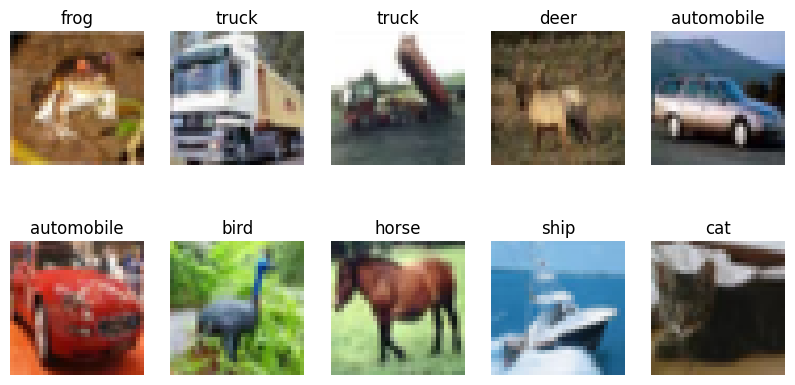

In [50]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [51]:
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


In [52]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [54]:
baseline_model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

In [55]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
baseline_history = baseline_model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.4631 - loss: 1.4702 - val_accuracy: 0.5436 - val_loss: 1.2630
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6077 - loss: 1.1077 - val_accuracy: 0.6488 - val_loss: 1.0062
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6757 - loss: 0.9301 - val_accuracy: 0.6790 - val_loss: 0.9259
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7161 - loss: 0.8107 - val_accuracy: 0.7006 - val_loss: 0.8701
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.7467 - loss: 0.7227 - val_accuracy: 0.7081 - val_loss: 0.8491


In [57]:
baseline_loss, baseline_acc = baseline_model.evaluate(
    x_test,
    y_test
)

print("Baseline Accuracy:", baseline_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7081 - loss: 0.8491
Baseline Accuracy: 0.7081000208854675


In [71]:
baseline_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,432 (4.08 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 713,622 (2.72 MB)

In [58]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [59]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',
    input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(10,activation='softmax')
])

In [60]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(
    datagen.flow(x_train,y_train,batch_size=64),
    epochs=20,
    validation_data=(x_test,y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - accuracy: 0.3570 - loss: 1.7434 - val_accuracy: 0.5067 - val_loss: 1.3368
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 116ms/step - accuracy: 0.4884 - loss: 1.4312 - val_accuracy: 0.5649 - val_loss: 1.2143
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 120ms/step - accuracy: 0.5381 - loss: 1.2949 - val_accuracy: 0.6132 - val_loss: 1.0800
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 116ms/step - accuracy: 0.5732 - loss: 1.2198 - val_accuracy: 0.6430 - val_loss: 1.0035
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.5955 - loss: 1.1596 - val_accuracy: 0.6679 - val_loss: 0.9416
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 119ms/step - accuracy: 0.6136 - loss: 1.1054 - val_accuracy: 0.6611 - val_loss: 0.9791
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 139s 116ms/step - accuracy: 0.6289 - loss: 1.0726 - val_accuracy: 0.6900 - val_loss: 0.8916
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 116ms/step - accuracy: 0.6391 - loss:

In [69]:
loss, improved_accuracy = model.evaluate(x_test,y_test)

print("Accuracy:",improved_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7377 - loss: 0.7714
Accuracy: 0.7376999855041504


In [70]:
print("="*40)
print("MODEL COMPARISON")
print("="*40)

print(f"Baseline CNN Accuracy : {baseline_acc:.4f}")
print(f"Improved CNN Accuracy : {improved_accuracy:.4f}")

improvement = (improved_accuracy- baseline_acc) * 100

print(f"Improvement : {improvement:.2f}%")

MODEL COMPARISON
Baseline CNN Accuracy : 0.7081
Improved CNN Accuracy : 0.7377
Improvement : 2.96%


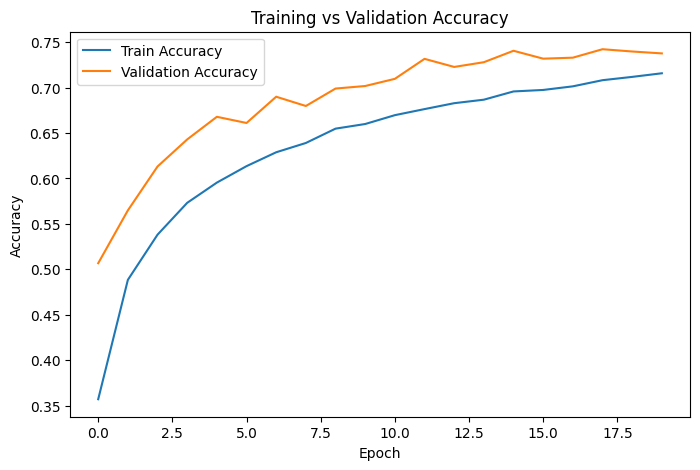

In [64]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

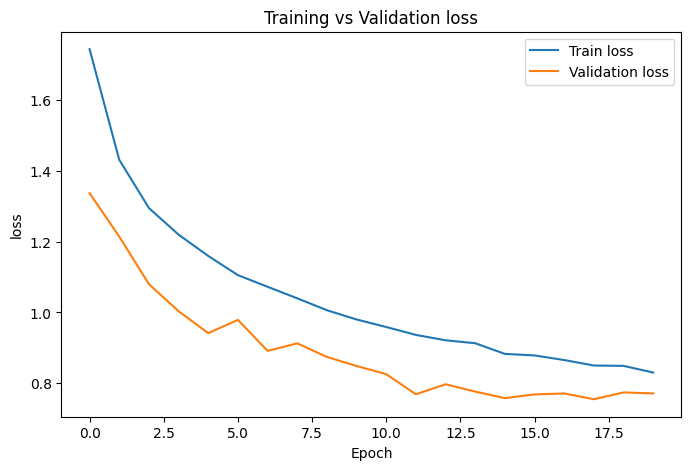

In [65]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title('Training vs Validation loss')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


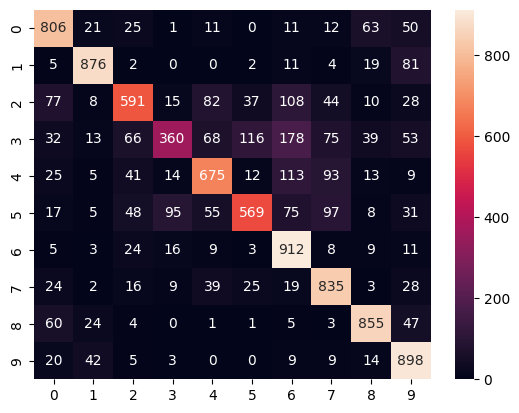

In [66]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(
    y_test,
    y_pred_classes
)

sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [67]:
sample = np.expand_dims(x_test[0], axis=0)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


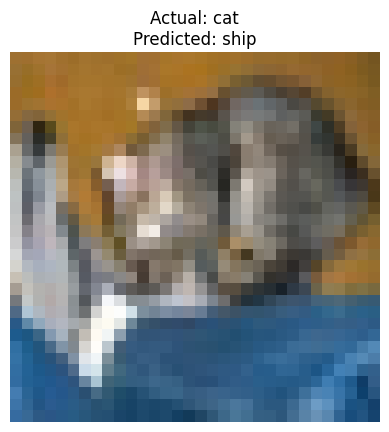

In [68]:
plt.imshow(x_test[0])
plt.title(
    f"Actual: {class_names[y_test[0][0]]}\n"
    f"Predicted: {class_names[predicted_class]}"
)
plt.axis('off')
plt.show()